In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

import category_encoders as ce

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [40]:
df = pd.read_csv('../data/employee-attrition.csv', index_col=0)
df.columns = df.columns.str.strip().str.lower()
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head(7)

Dataset shape: (1470, 34)

First 5 rows:


,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,...,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
Age,,,,,,,,,,,,,,,,,,,,,
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2
32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,...,3,80,0,8,2,2,7,7,3,6
59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,...,1,80,3,12,3,2,1,0,0,0


In [41]:
df['attrition'].value_counts()
# Dataset is very highly imabalanced

attrition
No     1233
Yes     237
Name: count, dtype: int64

In [42]:
attrition_mask = df['attrition'] == 'No'
gender_mask = df['gender'] == 'Male'
df['attrition'] = attrition_mask.astype(int)
df['gender'] = gender_mask.astype(int)
df.head(7)
# print(df.isnull().sum())

,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,...,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
Age,,,,,,,,,,,,,,,,,,,,,
41,0,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
49,1,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
37,0,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
33,1,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
27,1,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2
32,1,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,...,3,80,0,8,2,2,7,7,3,6
59,1,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,...,1,80,3,12,3,2,1,0,0,0


In [51]:
df.dtypes
cat_cols = df.select_dtypes(include=["str"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64"]).columns.drop('attrition').tolist()
print(len(num_cols), len(cat_cols))

26 7


In [53]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
x = df[cat_cols + num_cols]
y = df['attrition']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33,random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training set: (984, 33)
Test set: (486, 33)
Train class distribution: [167 817]
Test class distribution: [ 70 416]


In [54]:
ohe = ce.OneHotEncoder(cols=cat_cols)
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

print(f"After encoding - Training set: {X_train_encoded.shape}")
print(f"After encoding - Test set: {X_test_encoded.shape}")
print(f"New feature columns: {list(X_train_encoded.columns)}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Scaled features mean: {X_train_scaled.mean():.6f}")
print(f"Scaled features std: {X_train_scaled.std():.6f}")

After encoding - Training set: (984, 53)
After encoding - Test set: (486, 53)
New feature columns: ['businesstravel_1', 'businesstravel_2', 'businesstravel_3', 'department_1', 'department_2', 'department_3', 'educationfield_1', 'educationfield_2', 'educationfield_3', 'educationfield_4', 'educationfield_5', 'educationfield_6', 'jobrole_1', 'jobrole_2', 'jobrole_3', 'jobrole_4', 'jobrole_5', 'jobrole_6', 'jobrole_7', 'jobrole_8', 'jobrole_9', 'maritalstatus_1', 'maritalstatus_2', 'maritalstatus_3', 'over18_1', 'overtime_1', 'overtime_2', 'dailyrate', 'distancefromhome', 'education', 'employeecount', 'employeenumber', 'environmentsatisfaction', 'gender', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssince

In [55]:
def CMDisplay(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(values_format="d")
    plt.show()
    print(classification_report(y_test, y_pred, labels=[0,1], target_names=["attrition_yes(0)","attrition_no(1)"], zero_division=0))

## Simple Logistic Regression

Logistic Regression Baseline : Accuracy: 0.7387 | Recall: 0.7572 | Precision: 0.9238 | F1 Score: 0.8322 | ROC_AUC score: 0.6929
[[ 44  26]
 [101 315]]


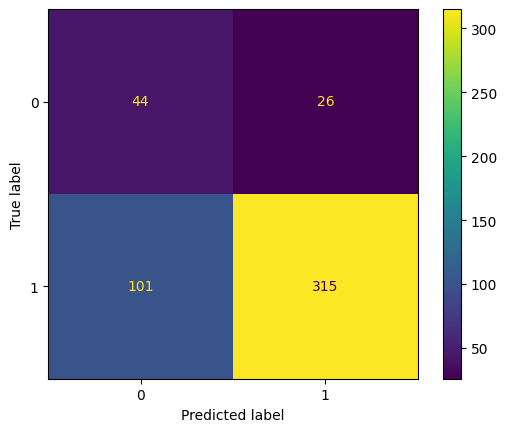

                  precision    recall  f1-score   support

attrition_yes(0)       0.30      0.63      0.41        70
 attrition_no(1)       0.92      0.76      0.83       416

        accuracy                           0.74       486
       macro avg       0.61      0.69      0.62       486
    weighted avg       0.83      0.74      0.77       486



In [151]:

lr_baseline = LogisticRegression(random_state=42, class_weight='balanced')
lr_baseline.fit(X_train_scaled, y_train)

y_pred_lr = lr_baseline.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
f1_score_lr = f1_score(y_test, y_pred_lr)
roc_auc_score_lr = roc_auc_score(y_test, y_pred_lr)

print(f"Logistic Regression Baseline : Accuracy: {accuracy_lr:.4f} | Recall: {rec_lr:.4f} | Precision: {prec_lr:.4f} | F1 Score: {f1_score_lr:.4f} | ROC_AUC score: {roc_auc_score_lr:.4f}")
CMDisplay(y_test, y_pred_lr)

## KNN Model

KNN Baseline : Accuracy: 0.7469 | Recall: 0.7981 | Precision: 0.8949 | F1 Score: 0.8437 | ROC_AUC score: 0.6205
[[ 31  39]
 [ 84 332]]


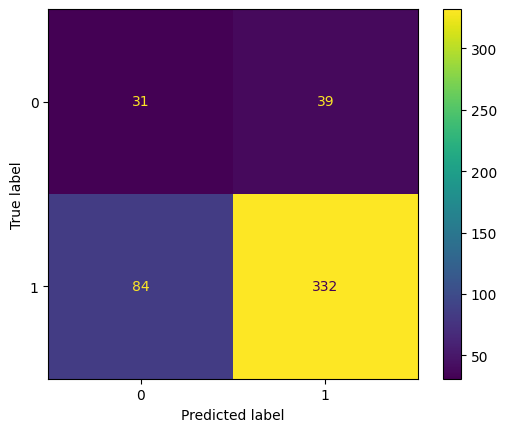

                  precision    recall  f1-score   support

attrition_yes(0)       0.27      0.44      0.34        70
 attrition_no(1)       0.89      0.80      0.84       416

        accuracy                           0.75       486
       macro avg       0.58      0.62      0.59       486
    weighted avg       0.80      0.75      0.77       486



In [112]:
k=2
knn_baseline = KNeighborsClassifier(n_neighbors=k, 
                                    p=2)
knn_baseline.fit(X_train_scaled, y_train)


y_pred_knn = knn_baseline.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
f1_score_knn = f1_score(y_test, y_pred_knn)
roc_auc_score_knn = roc_auc_score(y_test, y_pred_knn)
print(f"KNN Baseline : Accuracy: {accuracy_knn:.4f} | Recall: {rec_knn:.4f} | Precision: {prec_knn:.4f} | F1 Score: {f1_score_knn:.4f} | ROC_AUC score: {roc_auc_score_knn:.4f}")
CMDisplay(y_test, y_pred_knn)



## Decision Trees

Decision Tree Baseline : Accuracy: 0.81893 | Recall: 0.8678 | Precision: 0.9162 | F1 Score: 0.8914 | ROC_AUC score: 0.6982
[[ 37  33]
 [ 55 361]]


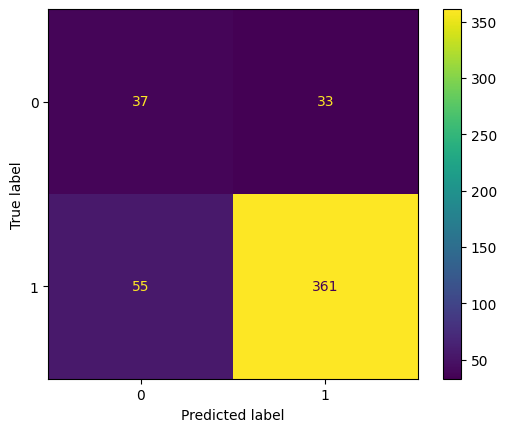

                  precision    recall  f1-score   support

attrition_yes(0)       0.40      0.53      0.46        70
 attrition_no(1)       0.92      0.87      0.89       416

        accuracy                           0.82       486
       macro avg       0.66      0.70      0.67       486
    weighted avg       0.84      0.82      0.83       486



In [148]:

# dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline = dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    ccp_alpha=0.001,   
    random_state=42,
    class_weight={0:4, 1:1}  
)
dt_baseline.fit(X_train_encoded, y_train)


y_pred_dt = dt_baseline.predict(X_test_encoded)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
f1_score_dt = f1_score(y_test, y_pred_dt)
roc_auc_score_dt = roc_auc_score(y_test, y_pred_dt)
print(f"Decision Tree Baseline : Accuracy: {accuracy_dt:.5f} | Recall: {rec_dt:.4f} | Precision: {prec_dt:.4f} | F1 Score: {f1_score_dt:.4f} | ROC_AUC score: {roc_auc_score_dt:.4f}")
CMDisplay(y_test, y_pred_dt)


## Random Forest

Random Forest : Accuracy: 0.8251 | Recall: 0.8774 | Precision: 0.9148 | F1 Score: 0.8957 | ROC_AUC score: 0.6958
[[ 36  34]
 [ 51 365]]


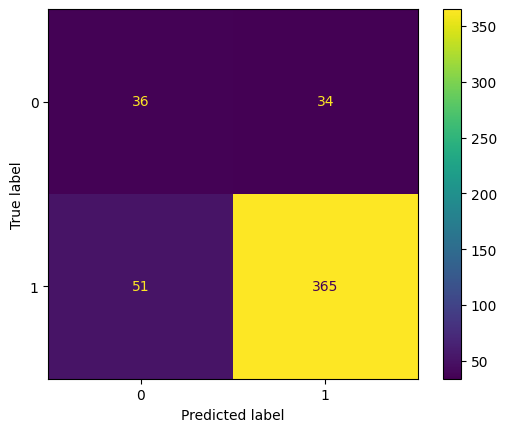

                  precision    recall  f1-score   support

attrition_yes(0)       0.41      0.51      0.46        70
 attrition_no(1)       0.91      0.88      0.90       416

        accuracy                           0.83       486
       macro avg       0.66      0.70      0.68       486
    weighted avg       0.84      0.83      0.83       486



In [115]:
# rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight={0:10, 1:1},  
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_encoded, y_train)

y_pred_rf = rf_baseline.predict(X_test_encoded)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf)
roc_auc_score_rf = roc_auc_score(y_test, y_pred_rf)
print(f"Random Forest : Accuracy: {accuracy_rf:.4f} | Recall: {rec_rf:.4f} | Precision: {prec_rf:.4f} | F1 Score: {f1_score_rf:.4f} | ROC_AUC score: {roc_auc_score_rf:.4f}")
CMDisplay(y_test, y_pred_rf)

## SVM

SVM Baseline : Accuracy: 0.8477 | Recall: 0.9159 | Precision: 0.9071 | F1 Score: 0.9115 | ROC_AUC score: 0.6794
[[ 31  39]
 [ 35 381]]


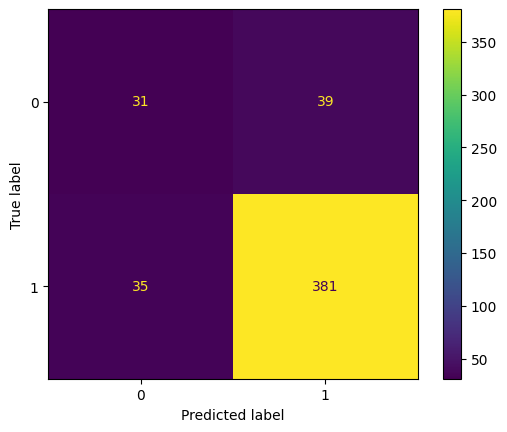

                  precision    recall  f1-score   support

attrition_yes(0)       0.47      0.44      0.46        70
 attrition_no(1)       0.91      0.92      0.91       416

        accuracy                           0.85       486
       macro avg       0.69      0.68      0.68       486
    weighted avg       0.84      0.85      0.85       486



In [117]:
# svm_baseline = SVC()
svm_baseline = SVC(
    kernel="rbf",
    C=1.0,               
    gamma="scale",
    class_weight={0:4, 1:1},
    probability=True,    
    random_state=42
)
svm_baseline.fit(X_train_scaled, y_train)

y_pred_svm = svm_baseline.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
f1_score_svm = f1_score(y_test, y_pred_svm)
roc_auc_score_svm = roc_auc_score(y_test, y_pred_svm)
print(f"SVM Baseline : Accuracy: {accuracy_svm:.4f} | Recall: {rec_svm:.4f} | Precision: {prec_svm:.4f} | F1 Score: {f1_score_svm:.4f} | ROC_AUC score: {roc_auc_score_svm:.4f}")
CMDisplay(y_test, y_pred_svm)

## Compare all models

Baseline Model Comparison:


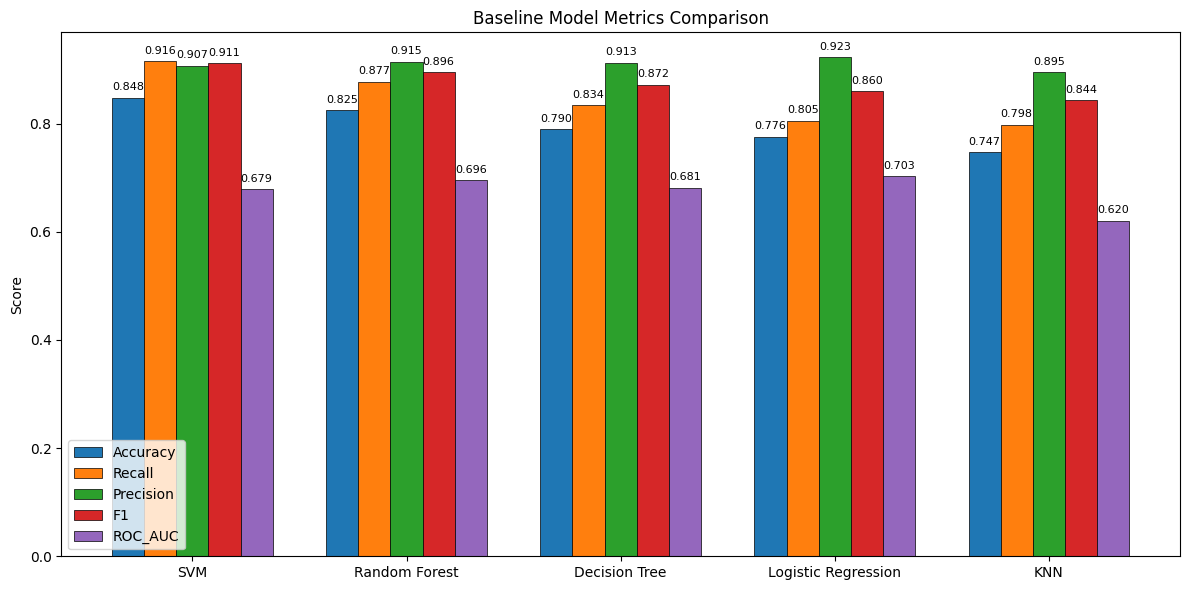

In [118]:
baseline_results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_lr, accuracy_knn, accuracy_dt, accuracy_rf, accuracy_svm],
    'Recall': [rec_lr, rec_knn, rec_dt, rec_rf, rec_svm],
    'Precision': [prec_lr, prec_knn, prec_dt, prec_rf, prec_svm],
    'F1': [f1_score_lr, f1_score_knn, f1_score_dt, f1_score_rf, f1_score_svm],
    'ROC_AUC': [roc_auc_score_lr, roc_auc_score_knn, roc_auc_score_dt, roc_auc_score_rf, roc_auc_score_svm]
}

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values('Accuracy', ascending=False)

print("Baseline Model Comparison:")

# Metrics you want to plot
metrics = ['Accuracy', 'Recall', 'Precision', 'F1', 'ROC_AUC']

# Number of models and metrics
n_models = len(baseline_df)
n_metrics = len(metrics)

# Set bar positions
x = np.arange(n_models)
width = 0.15  # width of each bar

# Create figure
plt.figure(figsize=(12, 6))

bars = []
# Plot each metric
for i, metric in enumerate(metrics):
    bar_group = plt.bar(
        x + i*width,
        baseline_df[metric],
        width,
        label=metric,
        edgecolor='black',       # ← border
        linewidth=0.5           # ← border thickness
    )
    bars.append(bar_group)

# Add value labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(x + width * (n_metrics/2 - 0.5), baseline_df['Model'])
plt.ylabel('Score')
plt.title('Baseline Model Metrics Comparison')
plt.legend()

plt.tight_layout()
plt.show()


## GRID SEARCH

In [119]:

# Logistic Regression parameters
lr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'l1_ratio': [0, 1],
    'solver':  ['liblinear', 'saga']
}

# KNN parameters
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# SVM parameters
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Decision Tree parameters
dt_param_grid = {
    'max_depth':  [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Random Forest parameters
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# Print parameter grid sizes
param_grids = {
    'Logistic Regression': lr_param_grid,
    'KNN': knn_param_grid,
    'SVM': svm_param_grid,
    'Decision Tree': dt_param_grid,
    'Random Forest': rf_param_grid
}

for model_name, param_grid in param_grids.items():
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    print(f"{model_name}: {total_combinations} parameter combinations")

Logistic Regression: 16 parameter combinations
KNN: 20 parameter combinations
SVM: 12 parameter combinations
Decision Tree: 45 parameter combinations
Random Forest: 36 parameter combinations


In [129]:

models = {
    'Logistic Regression': (lr_baseline, lr_param_grid, X_train_scaled),
    'KNN': (knn_baseline, knn_param_grid, X_train_scaled),
    'SVM': (svm_baseline, svm_param_grid, X_train_scaled),
    'Decision Tree': (dt_baseline, dt_param_grid, X_train_encoded),
    'Random Forest': (rf_baseline, rf_param_grid, X_train_encoded)
}

# Store results
grid_search_results = {}

scoring_metric = 'roc_auc' #to be decided



## LR Grid

In [130]:
lr_model, lr_grid, lr_data = models['Logistic Regression']

lr_grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1, 
    verbose=1  
)

lr_grid_search.fit(lr_data, y_train)

grid_search_results['Logistic Regression'] = lr_grid_search
print(f"✅ Best params: {lr_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {lr_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/MichaelAjanaku/Desktop/Capstone-Employee-Churn/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MichaelAjanaku/Desktop/Capstone-Employee-Churn/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MichaelAjanaku/Desktop/Capstone-Employee-Churn/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MichaelAjanaku/Desktop/Capstone-Employee-Churn/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MichaelAjanaku/Desktop/Capstone-Employee-Churn/venv/lib/python3.12/site-packages/sklearn/linear_model

✅ Best params: {'C': 0.1, 'l1_ratio': 1, 'solver': 'liblinear'}
✅ Best CV roc_auc: 0.8395



## KNN Grid

In [131]:
knn_model, knn_grid, knn_data = models['KNN']

knn_grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,
    verbose=1
)

knn_grid_search.fit(knn_data, y_train)

grid_search_results['KNN'] = knn_grid_search
print(f"✅ Best params: {knn_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {knn_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
✅ Best CV roc_auc: 0.7450



## Decision Trees Grid

In [132]:
dt_model, dt_grid, dt_data = models['Decision Tree']

dt_grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,  
    verbose=1  
)

dt_grid_search.fit(dt_data, y_train)


grid_search_results['Decision Tree'] = dt_grid_search
print(f"✅ Best params: {dt_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {dt_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
✅ Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
✅ Best CV roc_auc: 0.7167



## Random Forest Grid

In [133]:
rf_model, rf_grid, rf_data = models['Random Forest']

rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,  
    verbose=1  
)

rf_grid_search.fit(rf_data, y_train)


grid_search_results['Random Forest'] = rf_grid_search
print(f"✅ Best params: {rf_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {rf_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best params: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV roc_auc: 0.7972



## SVM Grid

In [134]:
svm_model, svm_grid, svm_data = models['SVM']

svm_grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_grid,
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,  
    verbose=1  
)

svm_grid_search.fit(svm_data, y_train)


grid_search_results['SVM'] = svm_grid_search
print(f"✅ Best params: {svm_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {svm_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
✅ Best CV roc_auc: 0.8376



In [135]:
final_results = []

for model_name, grid_search in grid_search_results.items():
    # Get the best model
    best_model = grid_search.best_estimator_

    # Choose appropriate test data (scaled vs encoded)
    if model_name in ['Logistic Regression', 'KNN', 'SVM']:
        X_test_data = X_test_scaled
    else:
        X_test_data = X_test_encoded

    # Make predictions
    y_pred = best_model.predict(X_test_data)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0.0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    final_results.append({
        'Model': model_name,
        'Best_CV_Score': grid_search.best_score_,
        'Test_Accuracy': accuracy,
        'Test_Precision': precision,
        'Test_Recall': recall,
        'Test_F1': f1
    })

    print(f"{model_name}:")
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  Test F1-Score: {f1:.4f}")
    print(f"  Test Recall-Score: {recall:.4f}")
    print(f"  Test Precision-Score: {precision:.4f}")
    print()

# Create results DataFrame
results_df = pd.DataFrame(final_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test_Accuracy', ascending=False)

print("\nFinal Model Comparison:")
print(results_df.to_string(index=False))

Logistic Regression:
  Best CV Score: 0.8395
  Test Accuracy: 0.7798
  Test F1-Score: 0.8036
  Test Recall-Score: 0.7798
  Test Precision-Score: 0.8474

KNN:
  Best CV Score: 0.7450
  Test Accuracy: 0.8663
  Test F1-Score: 0.8192
  Test Recall-Score: 0.8663
  Test Precision-Score: 0.8549

Decision Tree:
  Best CV Score: 0.7167
  Test Accuracy: 0.8292
  Test F1-Score: 0.8326
  Test Recall-Score: 0.8292
  Test Precision-Score: 0.8363

Random Forest:
  Best CV Score: 0.7972
  Test Accuracy: 0.7942
  Test F1-Score: 0.8113
  Test Recall-Score: 0.7942
  Test Precision-Score: 0.8378

SVM:
  Best CV Score: 0.8376
  Test Accuracy: 0.7695
  Test F1-Score: 0.7936
  Test Recall-Score: 0.7695
  Test Precision-Score: 0.8350


Final Model Comparison:
              Model  Best_CV_Score  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
                KNN         0.7450         0.8663          0.8549       0.8663   0.8192
      Decision Tree         0.7167         0.8292          0.8363       0.8292

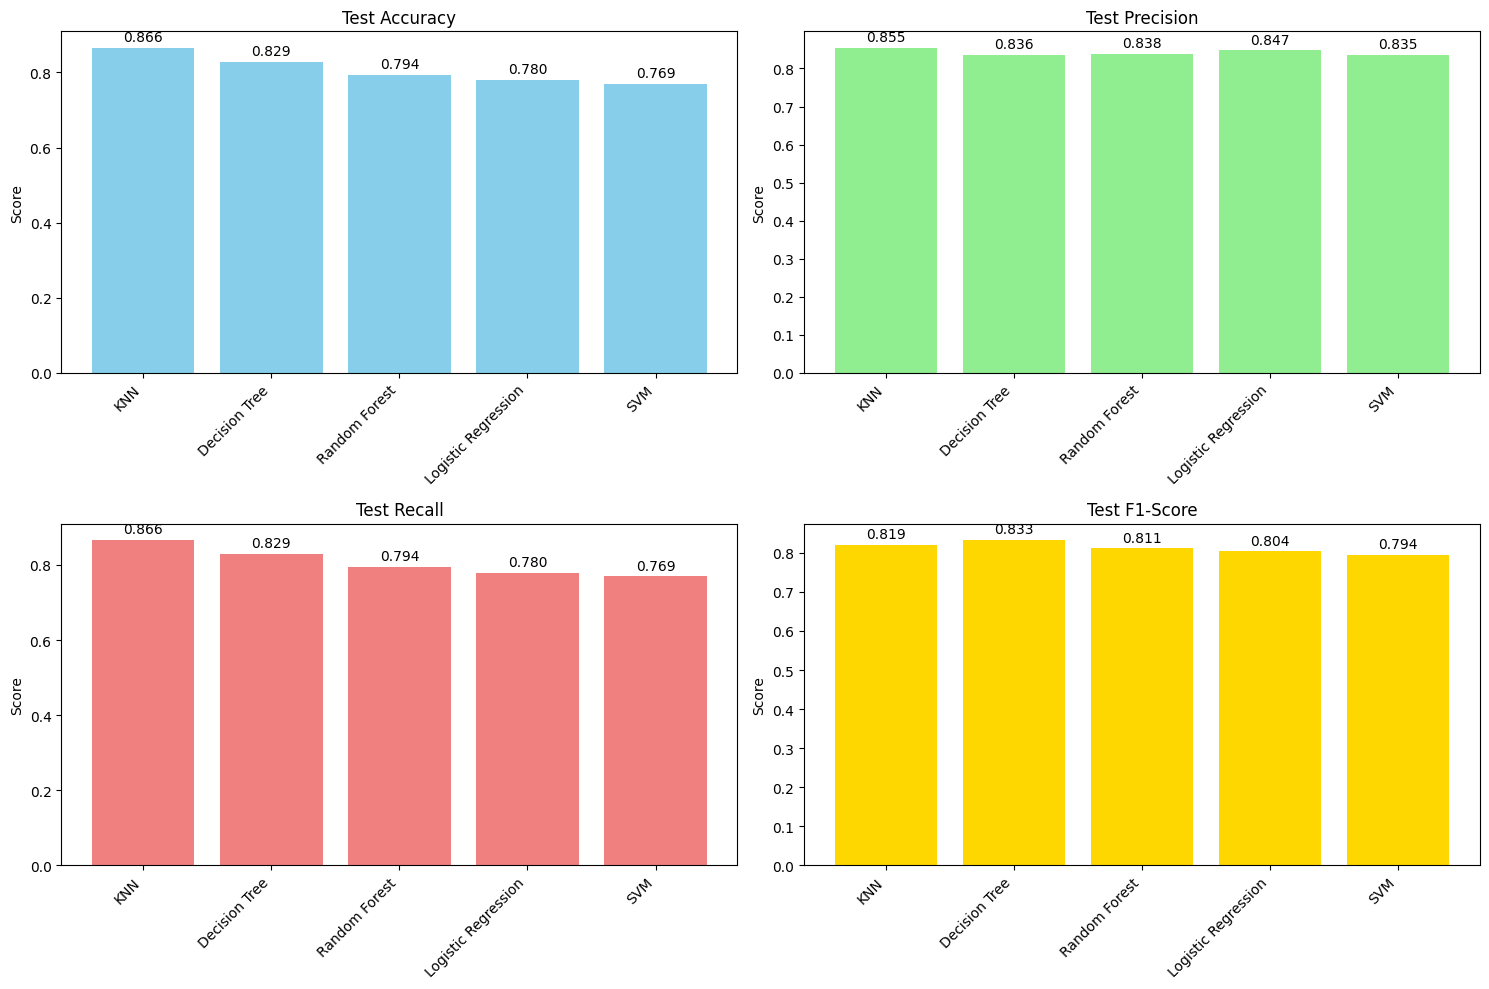

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1']
titles = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 2, idx % 2]

    bars = ax.bar(results_df['Model'], results_df[metric], color=color)
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', labelrotation=45)
    plt.setp(ax.get_xticklabels(), ha='right')


    
    for bar, value in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [146]:
best_model_name = results_df.iloc[0]['Model']
best_grid_search = grid_search_results[best_model_name]
best_model = best_grid_search.best_estimator_

print(f"🏆 Best Model: {best_model_name}")
print(f"Best Parameters: {best_grid_search.best_params_}")
print(f"Test Accuracy: {results_df.iloc[0]['Test_Accuracy']:.4f}")
print()

# Choose appropriate test data
if best_model_name in ['Logistic Regression', 'KNN', 'SVM']:
    X_test_best = X_test_scaled
else:
    X_test_best = X_test_encoded

y_pred_best = best_model.predict(X_test_best)

# Detailed classification report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['0', '1'], zero_division=0.0))

🏆 Best Model: KNN
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Test Accuracy: 0.8663

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.10      0.18        70
           1       0.87      1.00      0.93       416

    accuracy                           0.87       486
   macro avg       0.82      0.55      0.55       486
weighted avg       0.85      0.87      0.82       486



<Figure size 800x600 with 0 Axes>

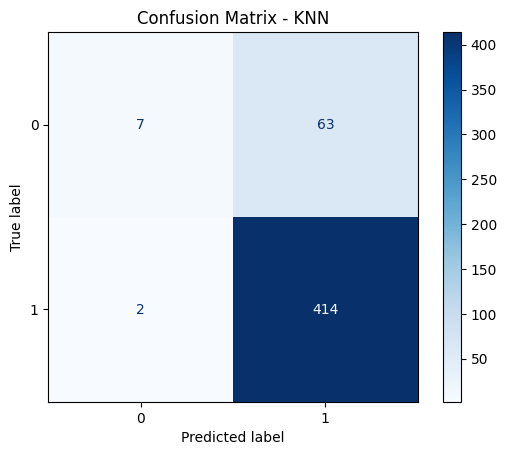

True Negatives (Correctly predicted 0): 7
False Positives (Incorrectly predicted 1): 63
False Negatives (Incorrectly predicted 0): 2
True Positives (Correctly predicted 1): 414


In [147]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# Calculate additional insights
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Correctly predicted 0): {tn}")
print(f"False Positives (Incorrectly predicted 1): {fp}")
print(f"False Negatives (Incorrectly predicted 0): {fn}")
print(f"True Positives (Correctly predicted 1): {tp}")